In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.0 MB 4.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/11.0 MB 3.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.6/11.0 MB 4.3 MB/s eta 0:00:02
   ------------ --------------------------- 3.4/11.0 MB 4.2 MB/s eta 0:00:02
   ---------------- ----------------------- 4.5/11.0 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/11.0 MB 4.1 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.0 MB 4.1 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.0 MB 4.0 MB/s eta 0:00:02
   --------------------------- ------------ 7.6/11.0 MB 4.1 MB/s eta 0:00:01
   ------------------------------- -------- 8.7/11.0 MB 4.1 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.0 MB 4.0 MB/s eta 0:00:01
   -------------------------------------- - 10.5/11.0 MB 4.1 MB/s eta 0:00:01
   --

In [1]:
import pandas as pd
import json

with open("extracted_oncology_data.json", "r") as f:
    data = json.load(f)

df = pd.json_normalize(data)
print("Rows:",df.shape[0],"Columns:",df.shape[1])
df.head()


Rows: 5 Columns: 21


,filename,title,publication_year,predicted_reliability,population.cancer_type,population.disease_stage,population.patient_age_range,population.sex_distribution,population.comorbidities_summary,population.prior_treatments_summary,...,design.sample_size,design.intervention,design.comparator,design.primary_endpoint,design.secondary_endpoints,design.followup_duration,results.primary_result_text,results.primary_result_numeric,results.safety_profile_summary,results.limitations_summary
0,PATINA_Pfizer.pdf,Pfizer’s IBRANCE® in Combination with Standard...,2024,High,"Hormone receptor-positive (HR+), human epiderm...",Metastatic,None,None,None,First-line maintenance therapy following induc...,...,518,IBRANCE® (palbociclib) in combination with ant...,Anti-HER2 therapy (trastuzumab or trastuzumab ...,Progression-free survival (PFS) as assessed by...,[Overall survival],None,The addition of IBRANCE® (palbociclib) to curr...,Median PFS was 44.3 months (95% CI: 32.4-60.9)...,The safety and tolerability of IBRANCE in the ...,"Overall survival, a secondary endpoint, was no..."
1,E1910_NICE.pdf,Blinatumomab with chemotherapy for consolidati...,2025,High,Philadelphia-chromosome-negative (Ph-negative)...,No measurable residual disease (MRD-negative) ...,Adults aged 30 to 70 years,None,None,Pre-phase chemotherapy + steroids +/- rituxima...,...,224,"Blinatumomab (4 cycles, each cycle = 28 mcg da...",Standard of care consolidation chemotherapy al...,Overall survival (OS),"[Relapse-free survival (RFS), Adverse events (...",Ongoing; 10-year follow-up from the start of i...,Trial results (E1910) suggest a step change im...,None,Blinatumomab is reported as well tolerated com...,Limitations include the exclusion of adults ag...
2,PALOMA-2_FDA.pdf,STATISTICAL REVIEW AND EVALUATION CLINICAL STU...,2015,High,"ER+, HER2 -first-line metastatic breast cancer",metastatic breast cancer,None,None,None,no prior systemic therapy for their advanced d...,...,165,Palbociclib in combination with letrozole,letrozole alone,investigator-assessed progression free surviva...,"[Overall Survival, Overall Response Rate]",Until disease progression or toxicity (treatme...,The primary analysis demonstrated a hazard rat...,0.488,None,PALOMA-1 was not designed to be a registration...
3,Personalized_Oncology_Meta_PLOS.pdf,Personal approach for cancer treatment: A meta...,2025,Medium,Various cancer types amenable to personalized ...,Includes advanced and metastatic disease stage...,Adults (18-85 years old),None,None,Included both pre-treated and treatment-naïve ...,...,6536,Personalized genomics-based cancer drug therap...,Non-personalized cancer drug treatment,Response Rate (RR),"[1-year Progression-Free Survival (PFS) rates,...","Variable across studies, with 1-year rates rep...",Personalized genomics-based cancer drug treatm...,Personalized treatment significantly improved ...,None,"High heterogeneity rates for RR, PFS, and OS a..."
4,DREAMseq_Results.pdf,EA6134 (DREAMseq) Clinical Trial Results Summa...,2023,High,Advanced melanoma with BRAF gene mutation,Stage III or IV unresectable melanoma,None,None,None,None,...,300,Immunotherapy drugs (nivolumab and ipilimumab)...,Targeted therapy drugs (dabrafenib and trameti...,Two-year survival,[],2 years,Patients did better with a treatment sequence ...,20% increase in two-year survival in the group...,None,None


In [10]:
# Fix empty columns, replace None with np.nan
df = df.replace({None: np.nan, "": np.nan})

# lower-case consistency
df.columns = [c.lower().replace(" ","_") for c in df.columns]

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   filename                             5 non-null      object 
 1   title                                5 non-null      object 
 2   publication_year                     5 non-null      int64  
 3   predicted_reliability                5 non-null      object 
 4   population.cancer_type               5 non-null      object 
 5   population.disease_stage             4 non-null      object 
 6   population.patient_age_range         2 non-null      object 
 7   population.sex_distribution          0 non-null      float64
 8   population.comorbidities_summary     1 non-null      object 
 9   population.prior_treatments_summary  4 non-null      object 
 10  design.study_type                    5 non-null      object 
 11  design.sample_size                  

C:\Users\pmlma\AppData\Local\Temp\ipykernel_45008\2206619119.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({None: np.nan, "": np.nan})


In [2]:
df=df.replace({"None":None,"":None})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   filename                             5 non-null      object
 1   title                                5 non-null      object
 2   publication_year                     5 non-null      int64 
 3   predicted_reliability                5 non-null      object
 4   population.cancer_type               5 non-null      object
 5   population.disease_stage             5 non-null      object
 6   population.patient_age_range         2 non-null      object
 7   population.sex_distribution          0 non-null      object
 8   population.comorbidities_summary     0 non-null      object
 9   population.prior_treatments_summary  4 non-null      object
 10  design.study_type                    5 non-null      object
 11  design.sample_size                   5 non-null  

Converting label to numeric target

In [3]:
label_map={"Low":0,"Medium":1,"High":2}
df["label"]=df["predicted_reliability"].map(label_map)

In [4]:
import numpy as np

# Study type one-hot encoding
df["is_rct"]=(df["design.study_type"]=="RCT").astype(int)
df["is_meta"]=(df["design.study_type"]=="Meta-Analysis").astype(int)
df["is_observ"]=df["design.study_type"].str.contains("Retrospective|Cohort",case=False,na=False).astype(int)

# Sample size bucketization
df["large_study"]=(df["design.sample_size"]>500).astype(int)
df["medium_study"]=((df["design.sample_size"]>200)&(df["design.sample_size"]<=500)).astype(int)
df["small_study"]=(df["design.sample_size"]<=200).astype(int)

# Comparator existence → control arm
df["has_control"]=df["design.comparator"].notna().astype(int)

# Follow-up duration → months extraction
def extract_months(x):
    if pd.isna(x): return np.nan
    x=x.lower()
    if "year" in x:
        yrs=[int(s) for s in x.split() if s.isdigit()]
        return yrs[0]*12 if yrs else np.nan
    if "month" in x:
        mos=[int(s) for s in x.split() if s.isdigit()]
        return mos[0] if mos else np.nan
    return np.nan

df["followup_months"]=df["design.followup_duration"].apply(extract_months)

# From text features
df["primary_is_survival"]=df["design.primary_endpoint"].str.contains("survival|OS|PFS",case=False,na=False).astype(int)
df["primary_is_response"]=df["design.primary_endpoint"].str.contains("response|RR",case=False,na=False).astype(int)

df["reported_safety"]=df["results.safety_profile_summary"].notna().astype(int)
df["reported_limitations"]=df["results.limitations_summary"].notna().astype(int)

# Year normalization
df["pub_year"]=df["publication_year"]
df["years_since_2015"]=df["pub_year"]-2015

df.head()


,filename,title,publication_year,predicted_reliability,population.cancer_type,population.disease_stage,population.patient_age_range,population.sex_distribution,population.comorbidities_summary,population.prior_treatments_summary,...,medium_study,small_study,has_control,followup_months,primary_is_survival,primary_is_response,reported_safety,reported_limitations,pub_year,years_since_2015
0,PATINA_Pfizer.pdf,Pfizer’s IBRANCE® in Combination with Standard...,2024,High,"Hormone receptor-positive (HR+), human epiderm...",Metastatic,None,None,None,First-line maintenance therapy following induc...,...,0,0,1,NaN,1,0,1,1,2024,9
1,E1910_NICE.pdf,Blinatumomab with chemotherapy for consolidati...,2025,High,Philadelphia-chromosome-negative (Ph-negative)...,No measurable residual disease (MRD-negative) ...,Adults aged 30 to 70 years,None,None,Pre-phase chemotherapy + steroids +/- rituxima...,...,1,0,1,NaN,1,0,1,1,2025,10
2,PALOMA-2_FDA.pdf,STATISTICAL REVIEW AND EVALUATION CLINICAL STU...,2015,High,"ER+, HER2 -first-line metastatic breast cancer",metastatic breast cancer,None,None,None,no prior systemic therapy for their advanced d...,...,0,1,1,NaN,1,0,0,1,2015,0
3,Personalized_Oncology_Meta_PLOS.pdf,Personal approach for cancer treatment: A meta...,2025,Medium,Various cancer types amenable to personalized ...,Includes advanced and metastatic disease stage...,Adults (18-85 years old),None,None,Included both pre-treated and treatment-naïve ...,...,0,0,1,NaN,0,1,0,1,2025,10
4,DREAMseq_Results.pdf,EA6134 (DREAMseq) Clinical Trial Results Summa...,2023,High,Advanced melanoma with BRAF gene mutation,Stage III or IV unresectable melanoma,None,None,None,None,...,1,0,1,24.0,1,0,0,0,2023,8


In [5]:
from sklearn.impute import SimpleImputer

features=["design.sample_size","is_rct","is_meta","is_observ","large_study",
          "medium_study","small_study","has_control","followup_months",
          "primary_is_survival","primary_is_response","reported_safety",
          "reported_limitations","pub_year","years_since_2015"]

X=df[features]
y=df["label"]

imputer=SimpleImputer(strategy="median")
X_imputed=imputer.fit_transform(X)

X=pd.DataFrame(X_imputed,columns=features)


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["combined_text"]=(
    df["results.primary_result_text"].fillna("")+" "+
    df["results.primary_result_numeric"].fillna("")+" "+
    df["results.safety_profile_summary"].fillna("")+" "+
    df["results.limitations_summary"].fillna("")
)

tfidf=TfidfVectorizer(max_features=200,stop_words="english")
text_vec=tfidf.fit_transform(df["combined_text"])

text_features=pd.DataFrame(text_vec.toarray(),columns=[f"t_{i}" for i in range(text_vec.shape[1])])

# Final feature matrix (structured + text)
final_features=pd.concat([X,text_features],axis=1)
final_features.shape


(5, 215)

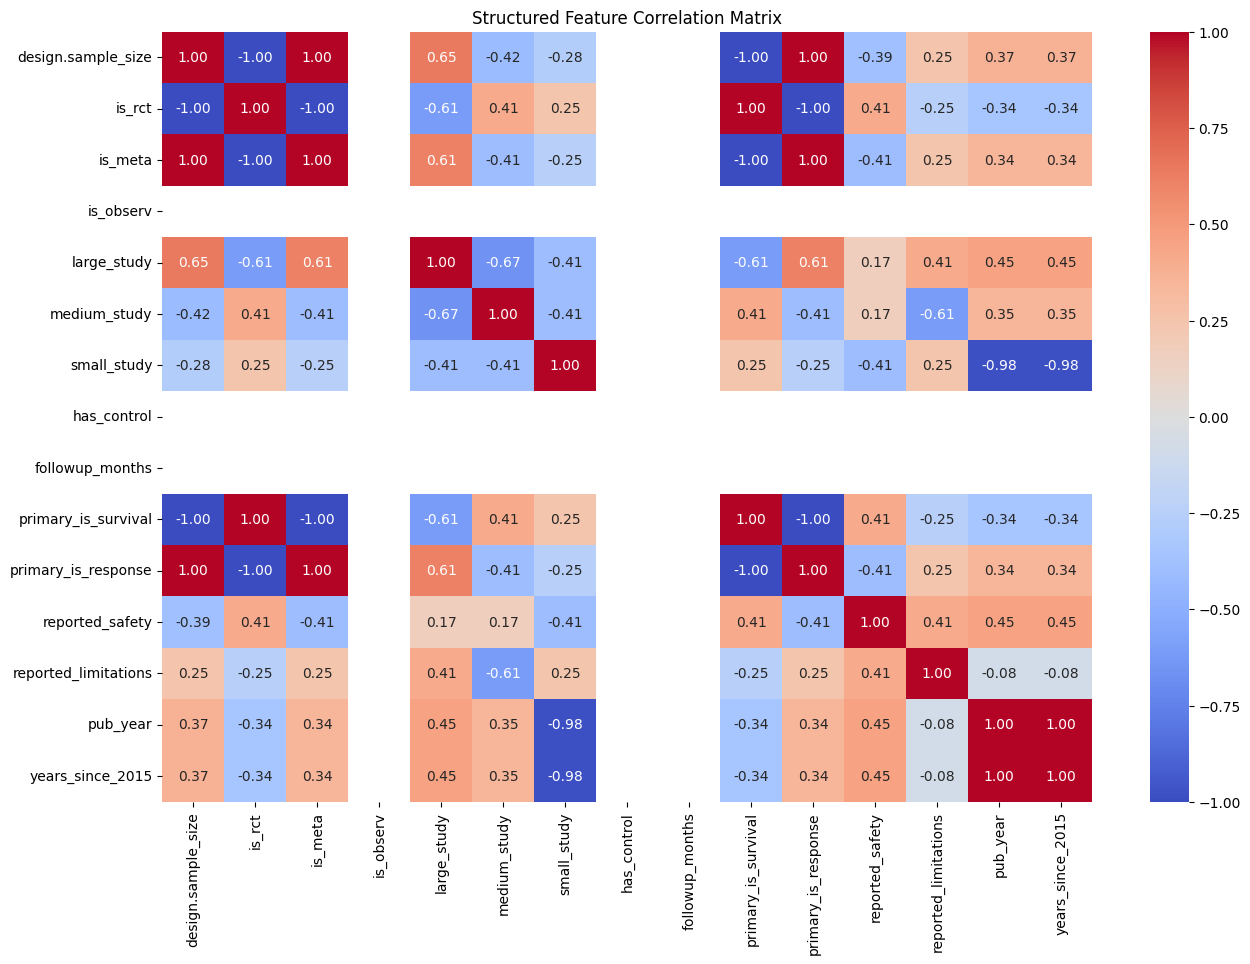

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
corr=X.corr()
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Structured Feature Correlation Matrix")
plt.show()


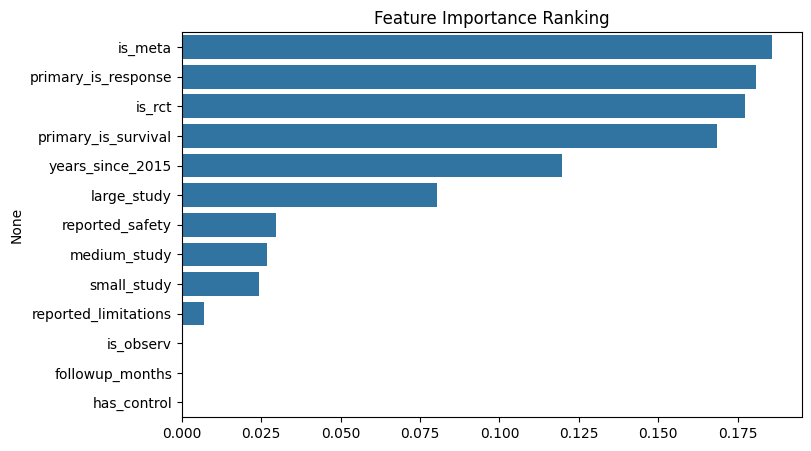

is_meta                 0.185883
primary_is_response     0.180651
is_rct                  0.177416
primary_is_survival     0.168379
years_since_2015        0.119673
large_study             0.080289
reported_safety         0.029680
medium_study            0.026826
small_study             0.024258
reported_limitations    0.006944
is_observ               0.000000
followup_months         0.000000
has_control             0.000000
dtype: float64

In [8]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

model = RandomForestClassifier().fit(
    df[[
        "is_rct","is_meta","is_observ",
        "large_study","medium_study","small_study",
        "has_control","followup_months",
        "primary_is_survival","primary_is_response",
        "reported_safety","reported_limitations",
        "years_since_2015"
    ]],
    df["label"]
)

importance = pd.Series(model.feature_importances_,
                       index=[
        "is_rct","is_meta","is_observ",
        "large_study","medium_study","small_study",
        "has_control","followup_months",
        "primary_is_survival","primary_is_response",
        "reported_safety","reported_limitations",
        "years_since_2015"
]).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importance.values,y=importance.index)
plt.title("Feature Importance Ranking")
plt.show()

importance
